In [1]:
!pip install scanpy
!pip install scanpy umap-learn
!pip install leidenalg
!pip install upsetplot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.4/276.4 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.5/53.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 89.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for upsetplot: filename=upsetplot-0.9.0-py3-none-any.whl size=24866 sha256=b04a0864fc7a36302dd967a162a7a4a0601931a586801b469409860718b9e519
  Stored in directory: /root/.cache/pip/wheels/5d/7a/54/1460364da0fe4e17c256b7a2819

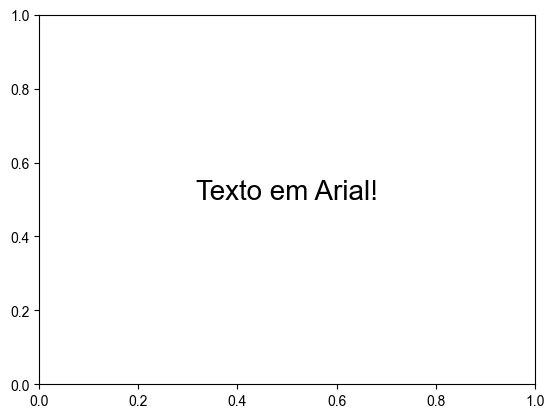

In [3]:
from matplotlib import font_manager as fm
import matplotlib as mpl
import matplotlib.pyplot as plt

# caminho para o seu arquivo TTF da Arial
# exemplo: se está na pasta atual
font_path = "/content/ARIAL.TTF"

# registra a fonte no matplotlib
fm.fontManager.addfont(font_path)

# define como padrão
mpl.rcParams['font.family'] = 'Arial'

# teste
plt.text(0.5, 0.5, "Texto em Arial!", fontsize=20, ha='center')

plt.show()

In [4]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import seaborn as sns

In [5]:
plt.rcParams['axes.labelsize'] = 26
plt.rcParams['axes.titlesize'] = 30
plt.rcParams['xtick.labelsize'] = 24
plt.rcParams['ytick.labelsize'] = 24
plt.rcParams['legend.fontsize'] = 24
plt.rcParams['font.family'] = 'Arial'

In [18]:
file_path = "Busca2_20250830_133923_20250830_Saliva_Cryopreserved_Patients_Library_Search_Report.tsv" #Spectronaut search with all patients (CTL, N0, N1, N3)
df = pd.read_csv(file_path, sep="\t", index_col=0)

original_col_count = df.shape[1]

df = df.loc[:, (df != 0).sum() >= 0]

filtered_col_count = df.shape[1]
removed_cols = original_col_count - filtered_col_count

print(f"{removed_cols} coluns were removed.")

0 coluns were removed.


In [19]:
exclude_df = pd.read_excel("Blanks_Common.xlsx") #PGs in common in all balnk raw files

ids_to_exclude = exclude_df.iloc[:, 0].tolist()

df = df[~df.iloc[:, 0].isin(ids_to_exclude)]

In [22]:
batch_map = {
    "20250717": "Control_OLDC", #CTL - Plate1
    "20250723": "N0_EPF", #pT2N0 - Plate 2
    "20250731": "Nodal_metastasis_VM",  #pT3N1 - Plate 3
    "20250818": "Nodal_metastasis_WAS" #pT3N3 - Plate 4
}

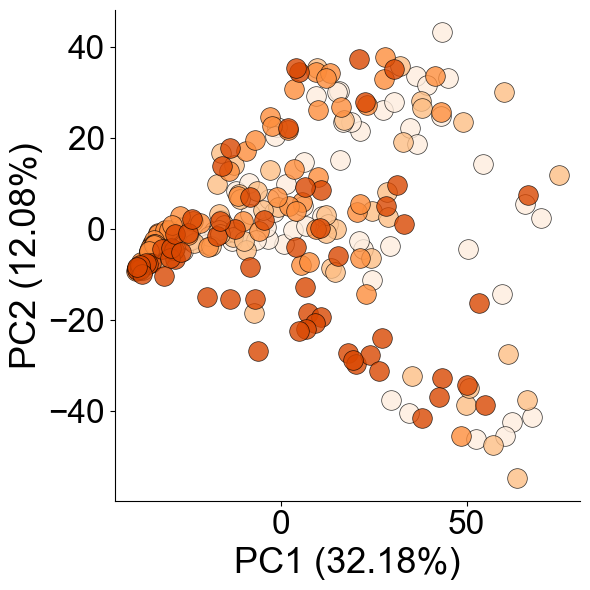

In [27]:
selected_columns = [col for col in df.columns if any(date in col for date in batch_map)]
df_filtered = df[selected_columns]

#Condtions are defined according to what is write between _

batch_labels = [col.split("_")[0].split("] ")[1] for col in df_filtered.columns]

df_filtered = df_filtered.fillna(0)
df_filtered = np.log1p(df_filtered)

adata = sc.AnnData(df_filtered.T)
adata.obs["batch"] = batch_labels

adata.uns["batch_colors"] = ['#feedde', '#fdbe85', "#fd8d3c", '#d94701']

sc.tl.pca(adata, n_comps=2)

adata.obs["batch_condition"] = [
    batch_map[date]
    for date in adata.obs["batch"]
]

sc.tl.pca(adata, n_comps=2)

pc1 = adata.obsm["X_pca"][:, 0]
pc2 = adata.obsm["X_pca"][:, 1]

batch_condition_colors = dict(zip(np.unique(adata.obs["batch_condition"]), adata.uns["batch_colors"]))

plt.figure(figsize=(6, 6))

for batch in np.unique(adata.obs["batch_condition"]):
    mask = np.array(adata.obs["batch_condition"]) == batch
    plt.scatter(
        pc1[mask],
        pc2[mask],
        label=batch,
        color=batch_condition_colors.get(batch, "#000000"),
        alpha=0.8,
        edgecolor='black',
        linewidth=0.5,
        s=200
    )

pc1_var = round(adata.uns["pca"]["variance_ratio"][0] * 100, 2)
pc2_var = round(adata.uns["pca"]["variance_ratio"][1] * 100, 2)

plt.xlabel(f"PC1 ({pc1_var}%)")
plt.ylabel(f"PC2 ({pc2_var}%)")
plt.title("")

#plt.legend(title="", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(False)
plt.tight_layout()



ax = plt.gca()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["bottom"].set_visible(True)
ax.spines["left"].set_visible(True)

ax.xaxis.set_ticks_position("bottom")
ax.yaxis.set_ticks_position("left")
plt.savefig("PG_PCA_batch_effect.svg", bbox_inches='tight')
plt.show()

/tmp/ipython-input-3314220300.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


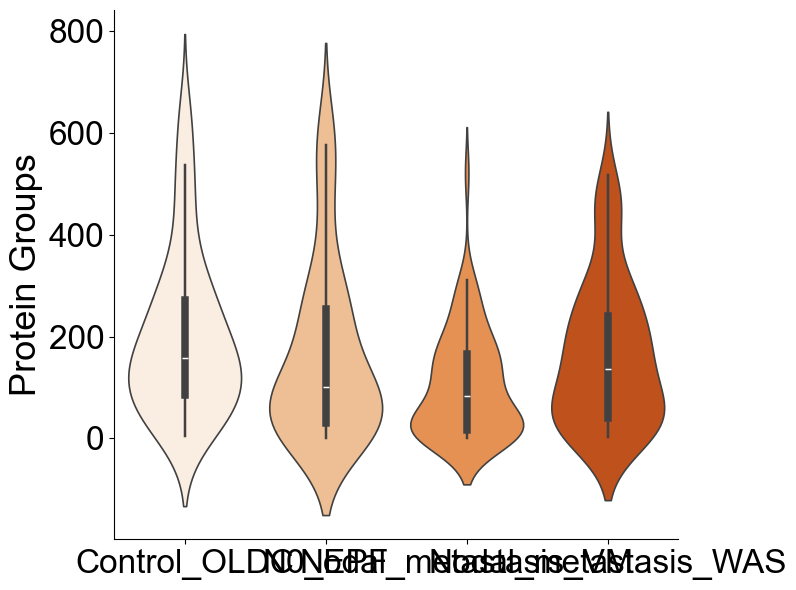

In [28]:

df_long = pd.DataFrame(df_filtered.T)
df_long["batch_condition"] = adata.obs["batch_condition"].values

protein_counts = (df[selected_columns].fillna(0) > 0).sum(axis=0)
df_counts = pd.DataFrame({
    "Sample": protein_counts.index,
    "ProteinCount": protein_counts.values,
    "Condition": [batch_map[s.split("_")[0].split("] ")[1]] for s in protein_counts.index]
})

plt.figure(figsize=(8,6))

sns.violinplot(
    data=df_counts,
    x="Condition", y="ProteinCount",
    palette=adata.uns["batch_colors"],
    inner="box",
    cut=2,
    linewidth=1.2
)

plt.ylabel("Protein Groups")
plt.xlabel("")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("Cells_PG_violin_conditions.svg", dpi=300)
plt.show()

Genes comuns a todas as condições (777):
['A2M', 'A2ML1', 'ACAA2', 'ACADVL', 'ACAT1', 'ACO2', 'ACOT9', 'ACOX1', 'ACSL1', 'ACTA2', 'ACTN1', 'ACTN4', 'ACTR2', 'ACTR3', 'ADAR', 'AGTRAP', 'AHCY', 'AHNAK', 'AK2', 'ALB', 'ALDH2', 'ALDH3B1', 'ALDH9A1', 'ALDOA', 'ALOX12B', 'ALOX5', 'ALOX5AP', 'AMPD3', 'AMY1B', 'ANO10', 'ANP32A', 'ANP32B', 'ANPEP', 'ANXA1', 'ANXA11', 'ANXA2', 'ANXA3', 'ANXA4', 'ANXA5', 'ANXA6', 'ANXA7', 'ANXA8', 'AP1G1', 'AP2M1', 'APEH', 'APEX1', 'APMAP', 'APOA1', 'APOBR', 'APOD', 'ARF3', 'ARG1', 'ARHGDIB', 'ARL6IP5', 'ARPC1B', 'ARPC2', 'ARPC3', 'ARPC4', 'ARPC5', 'ASAH1', 'ATP2A2', 'ATP2A3', 'ATP5F1A', 'ATP5F1B', 'ATP5F1C', 'ATP5MG', 'ATP5PB', 'ATP5PD', 'ATP5PF', 'ATP5PO', 'ATP6AP1', 'ATP6V0D1', 'ATP6V1A', 'ATP6V1B2', 'ATP6V1E1', 'AZGP1', 'AZU1', 'B2M', 'BASP1', 'BCAP31', 'BLMH', 'BPI', 'BPIFA1', 'BPIFA2', 'BPIFB1', 'BPIFB2', 'BRI3BP', 'BSG', 'BST1', 'C1QBP', 'C3', 'C4A', 'C4BPA', 'C5', 'C9', 'CA6', 'CALM1', 'CALML3', 'CALML5', 'CALR', 'CAMP', 'CANX', 'CAP1', 'CAPN1', 'CAPNS2',

/usr/local/lib/python3.12/dist-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/usr/local/lib/python3.12/dist-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/usr/local/lib/

<Figure size 1000x600 with 0 Axes>

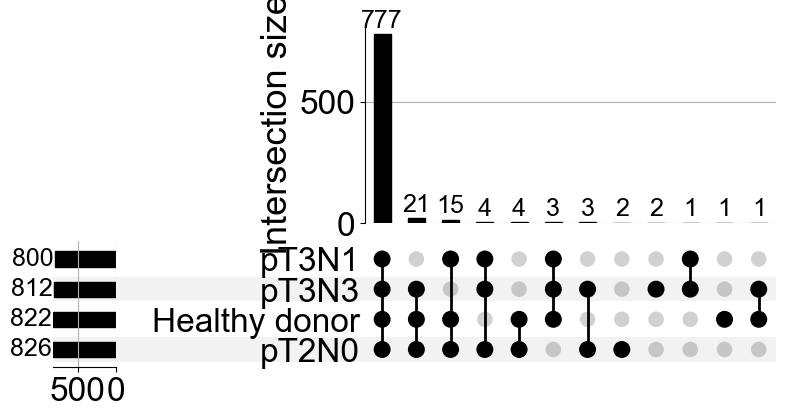

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from upsetplot import UpSet, from_memberships

plt.rcParams.update({"font.size": 18})

df = pd.read_csv(
    "Busca2_20250830_133923_20250830_Saliva_Cryopreserved_Patients_Library_Search_Report.tsv",
    sep="\t"
)

df = df.replace(0, pd.NA)

condicoes = ["Control_OLDC", "EPF", "Nodal_metastasis_VM", "Nodal_metastasis_WAS"]

rename_map = {
    "Control_OLDC": "Healthy donor",
    "EPF": "pT2N0",
    "Nodal_metastasis_VM": "pT3N1",
    "Nodal_metastasis_WAS": "pT3N3"
}

condicao_cols = {
    cond: [col for col in df.columns if cond in col]
    for cond in condicoes
}

genes_por_condicao = {
    rename_map[cond]: set(df.loc[df[cols].notna().any(axis=1), "PG.Genes"])
    for cond, cols in condicao_cols.items() if cols  # só entra se achar colunas
}

genes_comuns = set.intersection(*genes_por_condicao.values())
print(f"Genes comuns a todas as condições ({len(genes_comuns)}):")
print(sorted(genes_comuns))

memberships = []
for gene in df["PG.Genes"].unique():
    presente = [new_name for new_name, genes in genes_por_condicao.items() if gene in genes]
    if presente:
        memberships.append(presente)

upset_data = from_memberships(memberships)

plt.figure(figsize=(10,6))
UpSet(upset_data, subset_size="count", show_counts=True, sort_by="cardinality").plot()

plt.savefig("Cells_Upset_PG_violin_conditions.svg", dpi=300)
plt.show()


In [31]:
condition_colors = {
    "Control_OLDC":"#feedde",
    "N0_EPF": "#fdbe85",
    "Nodal_metastasis_VM":"#ea8500ff",
    "Nodal_metastasis_WAS": "#be501cff"
}

In [32]:
file_path = "Busca2_20250830_133923_20250830_Saliva_Cryopreserved_Patients_Library_Search_Report.tsv"
data = pd.read_csv(file_path, sep="\t", encoding='latin-1')

In [33]:
original_col_count = data.shape[1]
data = data.loc[:, (data != 0).sum() >= 0]

filtered_col_count = data.shape[1]
removed_cols = original_col_count - filtered_col_count

print(f"{removed_cols} coluns were removed.")

0 coluns were removed.


In [34]:
exclude_df = pd.read_excel("Blanks_Common.xlsx")

ids_to_exclude = exclude_df.iloc[:, 0].tolist()

data = data[~data.iloc[:, 0].isin(ids_to_exclude)]

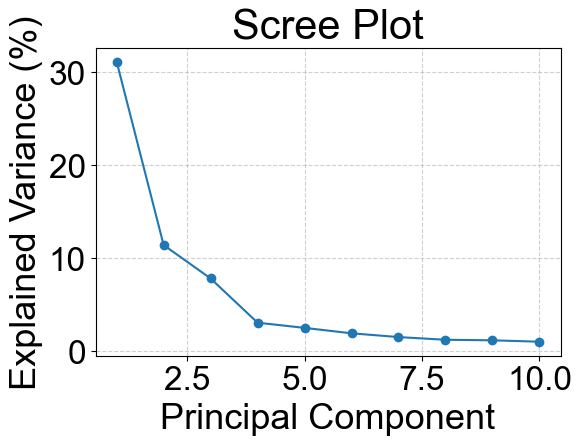

In [38]:
transposed_data = data.set_index("PG.Genes").transpose()

transposed_data = transposed_data.fillna(0)

valid_samples = [sample for sample in transposed_data.index if "_" in sample]

condition_keywords = list(condition_colors.keys())

def extract_condition(row_name):
    for keyword in condition_keywords:
        if keyword in row_name:
            return keyword
    return "Unknown"

sample_conditions = [extract_condition(row) for row in transposed_data.index]

colors = [condition_colors.get(condition, "#000000") for condition in sample_conditions]

adata = sc.AnnData(transposed_data.loc[valid_samples].values)
adata.obs["condition"] = sample_conditions

sc.pp.log1p(adata)

sc.tl.pca(adata, n_comps=10)

explained_variance_ratio = adata.uns["pca"]["variance_ratio"]

plt.figure(figsize=(6,4))
plt.plot(range(1, len(explained_variance_ratio)+1),
         explained_variance_ratio*100, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.title("Scree Plot")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

transposed_data.to_csv("Saliva_Cryopreserved_Patients_Library_Report_transposed.tsv", sep="\t")

In [46]:
from scipy.stats import pearsonr

In [47]:
adata = sc.AnnData(transposed_data.loc[valid_samples].values)
adata.obs_names = valid_samples
# Ensure var_names are strings
adata.var_names = transposed_data.columns.astype(str)
adata.obs["condition"] = sample_conditions

In [48]:
diameter_df = pd.read_excel("Busca2_Morphometrics_J4remove.xlsx")

diameter_df = diameter_df.set_index("Sample")

adata.obs["Diameter"] = diameter_df["Diameter"].values

sc.pp.log1p(adata)
sc.tl.pca(adata, n_comps=10)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

In [49]:
adata.obs["protein_count"] = (transposed_data.loc[valid_samples] > 0).sum(axis=1).values

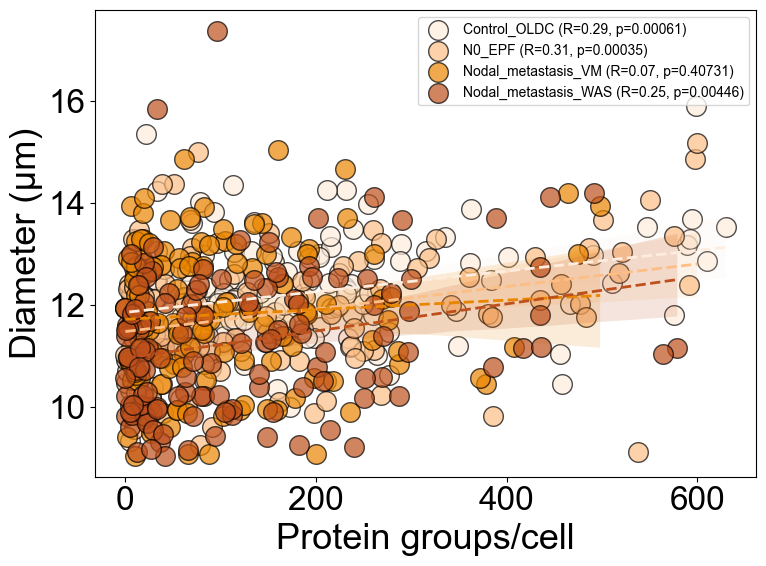

In [50]:
diameters = pd.to_numeric(adata.obs["Diameter"], errors='coerce').fillna(0)
protein_counts = pd.to_numeric(adata.obs["protein_count"], errors='coerce').fillna(0)
conditions = adata.obs["condition"]

df = pd.DataFrame({
    "Diameter": diameters,
    "ProteinGroups": protein_counts,
    "Condition": conditions
})

plt.figure(figsize=(8, 6))

for cond in df["Condition"].unique():
    sub = df[df["Condition"] == cond]
    r, p = pearsonr(sub["ProteinGroups"], sub["Diameter"])

    color = condition_colors.get(cond, "gray")

    sns.regplot(
        data=sub,
        x="ProteinGroups",
        y="Diameter",
        scatter_kws={"s": 200, "alpha": 0.7, "edgecolor": "black", "color": color},
        line_kws={"color": color, "linestyle": "--", "linewidth": 2},
        label=f"{cond} (R={r:.2f}, p={p:.5f})"
    )

plt.xlabel("Protein groups/cell")
plt.ylabel("Diameter (µm)")
plt.legend(fontsize=10, frameon=True)
plt.tight_layout()
plt.savefig("scatter_all_conditions.svg")
plt.show()

/tmp/ipython-input-3568934876.py:51: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


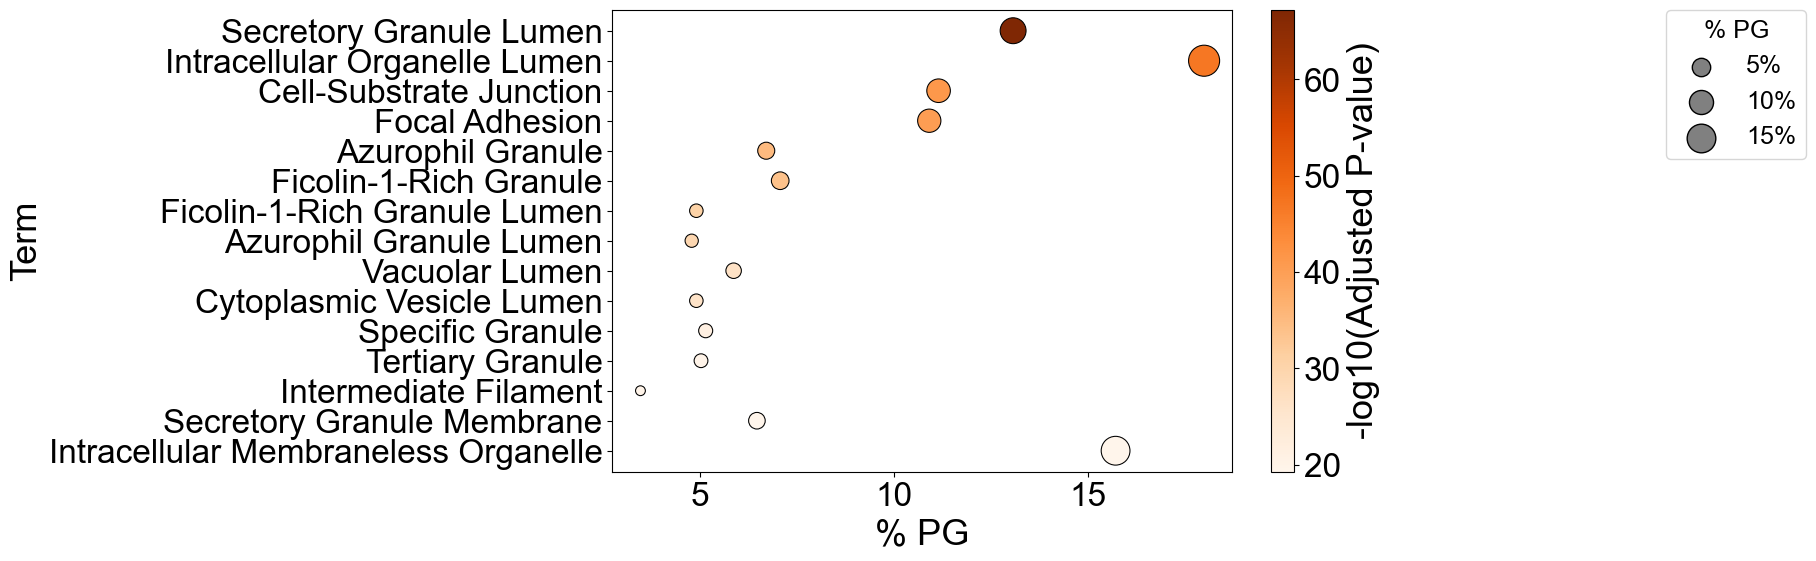

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("Saliva_GO_Cellular_Component_2025_table.txt", sep="\t")

df.rename(columns=lambda x: x.strip(), inplace=True)

df["-log10(Adj P)"] = -np.log10(df["Adjusted P-value"])

df_top = df.head(15)

plt.figure(figsize=(10,6))
ax = sns.scatterplot(
    data=df_top,
    x="% PG",
    y="Term",
    size="% PG",
    hue="-log10(Adj P)",
    palette="Oranges",
    sizes=(50, 500),
    edgecolor="black",
    legend=False
)

norm = plt.Normalize(df_top["-log10(Adj P)"].min(), df_top["-log10(Adj P)"].max())
sm = plt.cm.ScalarMappable(cmap="Oranges", norm=norm)
sm.set_array([])

cbar = ax.figure.colorbar(sm, ax=ax)
cbar.set_label("-log10(Adjusted P-value)")

size_values = [5, 10, 15]
size_handles = [
    plt.scatter([], [], s=(50 + (val/df_top["% PG"].max())*450),
                edgecolor="black", facecolor="gray")
    for val in size_values
]
ax.legend(
    size_handles,
    [f"{v}%" for v in size_values],
    title="% PG",
    title_fontsize=18,
    fontsize=18,
    bbox_to_anchor=(1.7, 1),
    loc=2,
    borderaxespad=0.
)

plt.tight_layout()
plt.savefig("Saliva_dotplot_CC_saliva_final.svg", bbox_inches='tight')
plt.show()


Quality Control (QC)

In [59]:
file_path = "20250902_043410_20250902_QC_HeLa_Cryopreserved_Saliva_Patients_Report.tsv"
df = pd.read_csv(file_path, sep="\t", index_col=0)

original_col_count = df.shape[1]

df = df.loc[:, (df != 0).sum() >= 0]

filtered_col_count = df.shape[1]
removed_cols = original_col_count - filtered_col_count

print(f"{removed_cols} colunas foram removidas.")

0 colunas foram removidas.


In [60]:
batch_map = {
    "20250717": "Control_OLDC",
    "20250723": "N0_HNSCC_EPF",
    "20250731": "Nodal_metastasis_VM",
    "20250818": "Nodal_metastasis_WAS"
}

In [66]:
selected_columns = [col for col in df.columns if any(date in col for date in batch_map)]
df_filtered = df[selected_columns]

batch_labels = [col.split("_")[0].split("] ")[1] for col in df_filtered.columns]

df_filtered = df_filtered.fillna(0)
df_filtered = np.log1p(df_filtered)

adata = sc.AnnData(df_filtered.T)
adata.obs["batch"] = batch_labels
adata.uns["batch_colors"] =  ['#b5cdf4ff', '#99b2d9ff', "#7d99baff", '#67779dff']

sc.tl.pca(adata, n_comps=2)

adata.obs["batch_condition"] = [
    batch_map[date]
    for date in adata.obs["batch"]
]

In [67]:
sc.tl.pca(adata, n_comps=2)

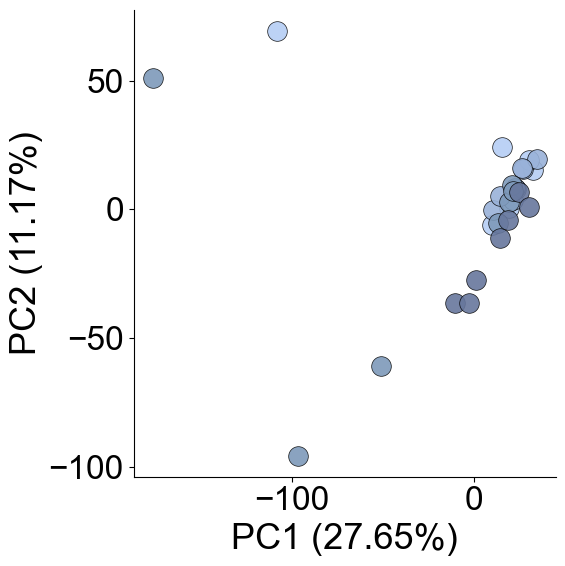

In [68]:
pc1 = adata.obsm["X_pca"][:, 0]
pc2 = adata.obsm["X_pca"][:, 1]

batch_condition_colors = dict(zip(np.unique(adata.obs["batch_condition"]), adata.uns["batch_colors"]))

plt.figure(figsize=(6, 6))

for batch in np.unique(adata.obs["batch_condition"]):
    mask = np.array(adata.obs["batch_condition"]) == batch
    plt.scatter(
        pc1[mask],
        pc2[mask],
        label=batch,
        color=batch_condition_colors.get(batch, "#000000"),
        alpha=0.9,
        edgecolor='black',
        linewidth=0.5,
        s=200
    )

pc1_var = round(adata.uns["pca"]["variance_ratio"][0] * 100, 2)
pc2_var = round(adata.uns["pca"]["variance_ratio"][1] * 100, 2)

plt.xlabel(f"PC1 ({pc1_var}%)")
plt.ylabel(f"PC2 ({pc2_var}%)")
plt.title("")

plt.grid(False)
plt.tight_layout()

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(True)
ax.spines["left"].set_visible(True)
ax.xaxis.set_ticks_position("bottom")
ax.yaxis.set_ticks_position("left")

plt.savefig("QC_PG_PCA_batch_effect.svg", bbox_inches='tight', dpi = 600)
plt.show()

/tmp/ipython-input-780016530.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


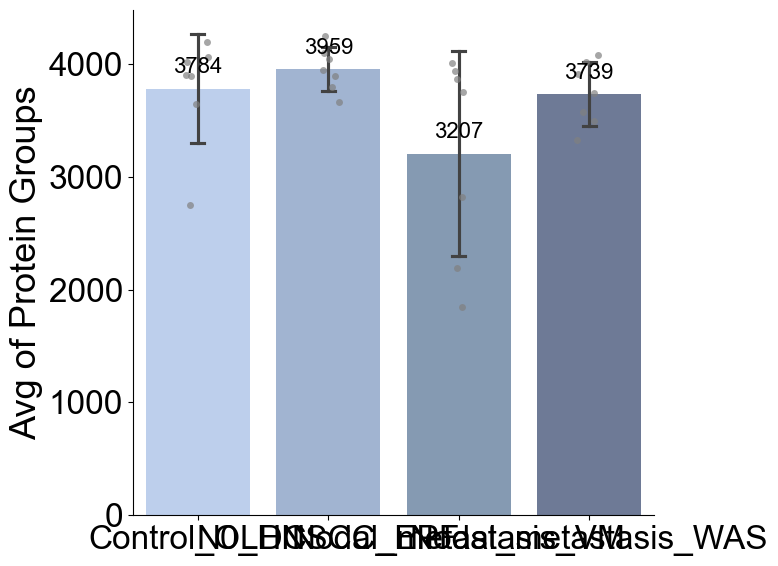

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

protein_counts = (df_filtered > 0).sum(axis=0)
df_counts = pd.DataFrame({
    "Sample": protein_counts.index,
    "ProteinCount": protein_counts.values,
    "Condition": [batch_map[s.split("_")[0].split("] ")[1]] for s in protein_counts.index]
})

plt.figure(figsize=(8,6))

sns.barplot(
    data=df_counts,
    x="Condition", y="ProteinCount",
    palette= ['#b5cdf4ff', '#99b2d9ff', "#7d99baff", '#67779dff'],
    errorbar="sd",
    capsize=0.1
)

sns.stripplot(
    data=df_counts,
    x="Condition", y="ProteinCount",
    color="gray", size=5, alpha=0.7,
    jitter=True
)

group_means = df_counts.groupby("Condition")["ProteinCount"].mean()
for i, (cond, mean_val) in enumerate(group_means.items()):
    plt.text(
        i, mean_val + 100, f"{int(mean_val)}",
        ha="center", va="bottom", fontsize=16, fontweight="bold"
    )

plt.ylabel("Avg of Protein Groups")
plt.xlabel("")

plt.tight_layout()


ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(True)
ax.spines["left"].set_visible(True)
ax.xaxis.set_ticks_position("bottom")
ax.yaxis.set_ticks_position("left")


plt.savefig("QC_barplot_protein_groups_conditions.svg", dpi=300)
plt.show()

/tmp/ipython-input-3439049565.py:53: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


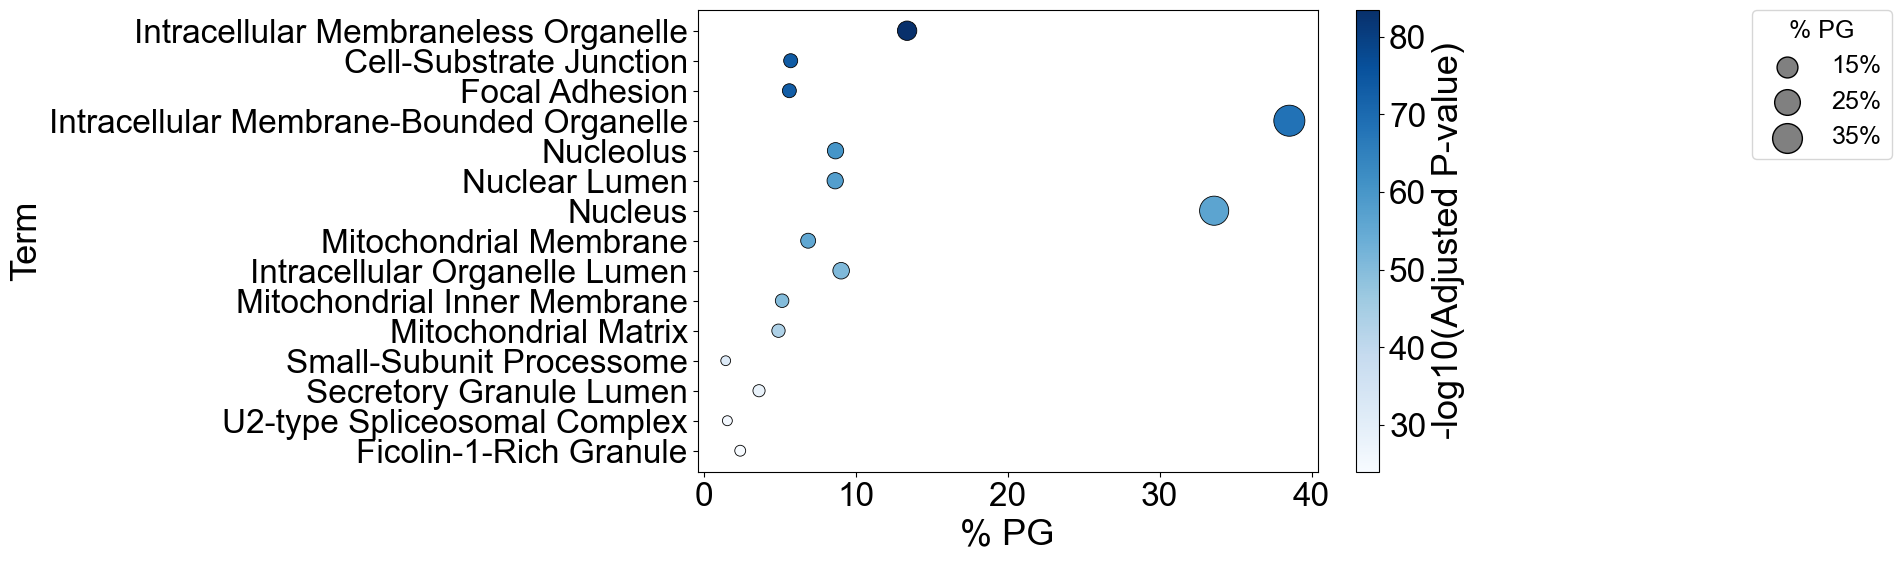

In [69]:
#Cellular component HeLa QC

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("Hela_QC_GO_Cellular_Component_2025_table.txt", sep="\t")

df.rename(columns=lambda x: x.strip(), inplace=True)

df["-log10(Adj P)"] = -np.log10(df["Adjusted P-value"])

df_top = df.head(15)

plt.figure(figsize=(10,6))
ax = sns.scatterplot(
    data=df_top,
    x="% PG",
    y="Term",
    size="% PG",
    hue="-log10(Adj P)",
    palette="Blues",
    sizes=(50, 500),
    edgecolor="black",
    legend=False  #
)

norm = plt.Normalize(df_top["-log10(Adj P)"].min(), df_top["-log10(Adj P)"].max())
sm = plt.cm.ScalarMappable(cmap="Blues", norm=norm)
sm.set_array([])

cbar = ax.figure.colorbar(sm, ax=ax)
cbar.set_label("-log10(Adjusted P-value)")

size_values = [15, 25, 35]
size_handles = [
    plt.scatter([], [], s=(50 + (val/df_top["% PG"].max())*450),
                edgecolor="black", facecolor="gray")
    for val in size_values
]
ax.legend(
    size_handles,
    [f"{v}%" for v in size_values],
    title="% PG",
    title_fontsize=18,
    fontsize=18,
    bbox_to_anchor=(1.7, 1),
    loc=2,
    borderaxespad=0.
)

plt.tight_layout()
plt.savefig("Hela_Benchmarking_dotplot_CC_saliva_final.svg", bbox_inches='tight')
plt.show()


/tmp/ipython-input-3440840983.py:53: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


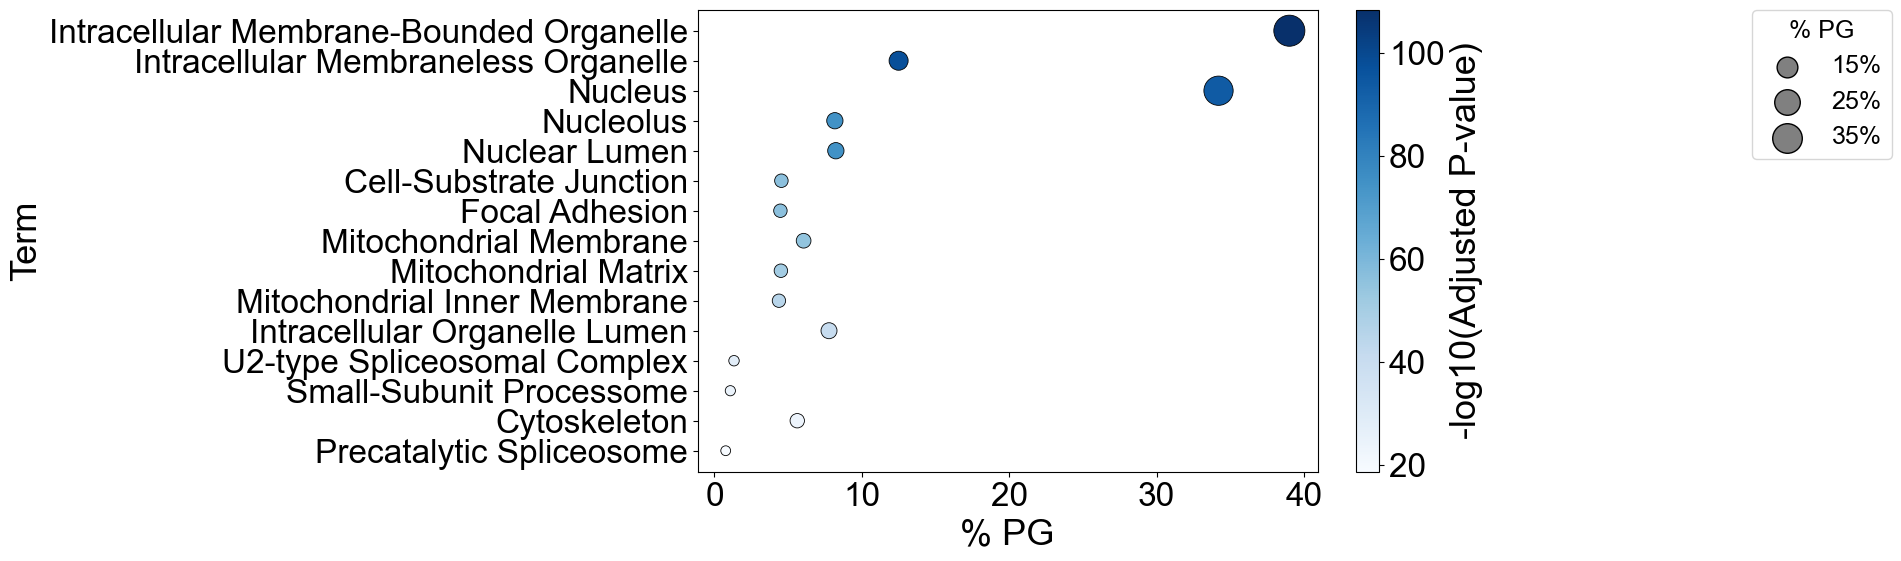

In [70]:
#Cellular component HeLa Benchmarking (Fresh and Cryopreserved)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("GO_Cellular_Component_2025_table.txt", sep="\t")

df.rename(columns=lambda x: x.strip(), inplace=True)

df["-log10(Adj P)"] = -np.log10(df["Adjusted P-value"])

df_top = df.head(15)

plt.figure(figsize=(10,6))
ax = sns.scatterplot(
    data=df_top,
    x="% PG",
    y="Term",
    size="% PG",
    hue="-log10(Adj P)",
    palette="Blues",
    sizes=(50, 500),
    edgecolor="black",
    legend=False  #
)

norm = plt.Normalize(df_top["-log10(Adj P)"].min(), df_top["-log10(Adj P)"].max())
sm = plt.cm.ScalarMappable(cmap="Blues", norm=norm)
sm.set_array([])

cbar = ax.figure.colorbar(sm, ax=ax)
cbar.set_label("-log10(Adjusted P-value)")

size_values = [15, 25, 35]
size_handles = [
    plt.scatter([], [], s=(50 + (val/df_top["% PG"].max())*450),
                edgecolor="black", facecolor="gray")
    for val in size_values
]
ax.legend(
    size_handles,
    [f"{v}%" for v in size_values],
    title="% PG",
    title_fontsize=18,
    fontsize=18,
    bbox_to_anchor=(1.7, 1),
    loc=2,
    borderaxespad=0.
)

plt.tight_layout()
plt.savefig("Hela_Benchmarking_dotplot_CC_saliva_final.svg", bbox_inches='tight')
plt.show()
